# Certified robustness of quantum spin textures

Companion notebook for **Certified robustness of quantum spin textures under magnetic-field perturbations**.

The analytical results hold for arbitrary spin $s$. These computations specialize to the linear spin-$1/2$ chiral Heisenberg model with a prescribed upward-polarized exterior. All supplied calculations use $J=a=\hbar=1$, $D=2$, and $K=0$. The magnetic field $B$ is the continuation parameter. The transverse-field example uses $(h_x,h_y)=(0.2,0.07)$ at the central site.

The general certificate $R_B=\Delta\Gamma/[Ns(2s+\Gamma)]$ reduces here to $2\Delta\Gamma/[N(1+\Gamma)]$. The paper proves $\Theta(1/N)$ scaling under uniform positive gap and geometric-margin bounds; the two flake sizes below do not establish such asymptotics numerically.

Run this notebook from the extracted submission package. The default cells verify the saved exact certificates, recompute the seven-spin analysis, record the field refinement and conditional sensitivity envelopes, and regenerate the geometry schematic and two figures of numerical results. Set `RUN_LARGE=True` to recompute the nineteen-spin scan and additional checks. These larger calculations have already been performed separately for the supplied data.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
from IPython.display import display, Image

cwd = Path.cwd()
if (cwd / "physical_model.py").is_file():
    supplement = cwd
elif (cwd / "supplement" / "physical_model.py").is_file():
    supplement = cwd / "supplement"
else:
    raise FileNotFoundError("Open this notebook inside the extracted supplement or manuscript directory.")
sys.path.insert(0, str(supplement))
data = supplement / "data"
print("Supplement:", supplement)
print("Model: physical chiral Heisenberg Hamiltonian; prescribed exterior; no state-dependent coefficients.")

Supplement: /workspace/scratch/ed2e573f4eb0/output/skyrmion_physical_submission/supplement
Model: physical chiral Heisenberg Hamiltonian; prescribed exterior; no state-dependent coefficients.


## Verify the saved mathematical certificates

Floating-point eigenvectors are only proposals. The verifier loads the saved quantized eigenbases, bounds their orthogonality and residual errors using integer/rational arithmetic, encloses all 128 eigenvalues, verifies separating vectors, and counts the degree by exact determinant signs.

In [2]:
from check_saved_certificates import verify
assert verify()
certified = json.loads((data / "exact_certificates.json").read_text())
for row in certified:
    print(f"B={row['B']}, h=({row['hx']},{row['hy']}): Q={row['Q_certified']}, "
          f"gap > {row['gap_lower']:.9f}, Gamma > {row['Gamma_lower']:.9f}")

Verified B=0.2, h_perp=(0,0): Q=-1
Verified B=0.648, h_perp=(0.2,0.07): Q=-1
Verified B=0.6485, h_perp=(0.2,0.07): Q=0
Verified B=0.649, h_perp=(0.2,0.07): Q=0
All saved exact-arithmetic certificates and the interval implications verified.
B=0.2, h=(0,0): Q=-1, gap > 0.894236457, Gamma > 0.306394204
B=0.648, h=(0.2,0.07): Q=-1, gap > 0.071226326, Gamma > 0.005761263
B=0.6485, h=(0.2,0.07): Q=0, gap > 0.070726923, Gamma > 0.001045770
B=0.649, h=(0.2,0.07): Q=0, gap > 0.070257837, Gamma > 0.007992058


## Recompute the seven-spin data

This reruns the symmetric and transverse-field scans, locates the geometric event, and rebuilds all four exact-arithmetic certificates. The event root is a numerical localization. The existence of a charge-changing obstruction with positive gap and local polarizations follows from the certified endpoint charges and uniform interval bounds.

In [3]:
from run_analysis import scan_small, certificates, provenance
event = scan_small()
new_certificates = certificates()
provenance()
print(f"Numerical face event: B/J = {event['row']['B']:.12f}")
print("Affected face:", event['face'])
print("Interior barycentric coefficients:", event['barycentric_weights'])
from fractions import Fraction
interval = json.loads((data / "interval_certificate.json").read_text())
print("Uniform gap lower bound:", float(Fraction(interval['gap_lower'])))
print("Uniform polarization lower bound:", float(Fraction(interval['polarization_lower'])))

Numerical face event: B/J = 0.648423852713
Affected face: [0, 1, 3]
Interior barycentric coefficients: [0.6119209638865999, 0.2569904989597643, 0.1310885371536359]
Uniform gap lower bound: 0.06722692331549884
Uniform polarization lower bound: 0.4424533505609413


## Optional nineteen-spin reproduction

The supplied nineteen-spin calculation uses the full 524,288-dimensional Hilbert space, without a mean-field or product-state ansatz. Allow several minutes and several GB of available memory. Independent random components in the starting vectors avoid confinement to a polarized invariant subspace. These larger-system results have residual and independent-start checks, but no exact spectral-ordering certificate.

In [4]:
RUN_LARGE = False
if RUN_LARGE:
    from run_analysis import scan_large
    from verify_numerics import verify as verify_numerics
    scan_large()
    verify_numerics(large=True)
else:
    print("Using the supplied, previously computed nineteen-spin data.")
large = json.loads((data / "n19_scan.json").read_text())
print(f"Saved nineteen-spin field values: {len(large)}")
print("Maximum saved eigenpair residual:", max(row['max_residual'] for row in large))

Using the supplied, previously computed nineteen-spin data.
Saved nineteen-spin field values: 16
Maximum saved eigenpair residual: 3.514155210658971e-11


## Field refinement and sensitivity

The scan uses steps of $0.0005J$. Its adjacent charge-change samples bracket the obstruction on $[0.6480,0.6485]J$. The interval certified in the paper is $[0.6480,0.6490]J$; its midpoint supplies uniform gap and polarization bounds. The root below is a numerical localization, not a verified decimal root.

For $N=19$, the illustrative budgets $\epsilon_m=10^{-6}$ and $\epsilon_\Delta=10^{-6}J$ produce **conditional** bounds: the budgets are assumptions, not verified error estimates or confidence intervals. Independent solver discrepancies are a separate empirical diagnostic. Neither excludes a missed lower eigenvalue.

In [5]:
from sensitivity_analysis import field_bracket, sensitivity_intervals, repeated_large_solves
bracket = field_bracket()
print("Adjacent charge-change bracket:", bracket["adjacent_charge_change_bracket"])
print("Brent root:", bracket["root"])
print("Verified interval and reference:", bracket["verified_interval"], bracket["verified_midpoint"])
sensitivity = sensitivity_intervals(eps_m=1e-6, eps_gap=1e-6)
print(sensitivity["kind"])
for row in sensitivity["rows"]:
    if row["B"] in (0., 1.4):
        print("B/J =", row["B"], "conditional R_B/J interval =", row["R_B_interval"])
if RUN_LARGE:
    repeated_large_solves()
repeats = json.loads((data / "n19_repeated_solves.json").read_text())
print(repeats["interpretation"])
for row in repeats["runs"]:
    print(f"B/J={row['B']}: moment discrepancy {row['max_site_moment_difference']:.3g}; "
          f"gap discrepancy {row['gap_difference']:.3g}; same charge {row['same_charge']}")

Adjacent charge-change bracket: [0.648, 0.6485]
Brent root: 0.6484238527131564
Verified interval and reference: [0.648, 0.649] 0.6485
Conditional deterministic sensitivity envelopes, not verified eigensystem bounds
B/J = 0.0 conditional R_B/J interval = [0.0320235661196833, 0.03202374142390665]
B/J = 1.4 conditional R_B/J interval = [0.009145710999275875, 0.009145804480661114]
Empirical solver agreement, not a certified error bound
B/J=0.0: moment discrepancy 6.58e-15; gap discrepancy 1.85e-13; same charge True
B/J=0.4: moment discrepancy 1.3e-14; gap discrepancy 6.75e-14; same charge True
B/J=1.4: moment discrepancy 8.9e-15; gap discrepancy 2.77e-13; same charge True
B/J=2.0: moment discrepancy 6.83e-15; gap discrepancy 4.9e-13; same charge True


## Regenerate the manuscript figures

Vector PDF figures and PNG previews are written to `../figures/`, where the LaTeX manuscript expects them. The first figure illustrates the projection construction with schematic moment coordinates. A gap between line segments in the numerical field scans indicates a change of charge between samples; it is not a resolved phase boundary.

admissibility_geometry.pdf
flakes_and_bounds.pdf
gapped_charge_change.pdf


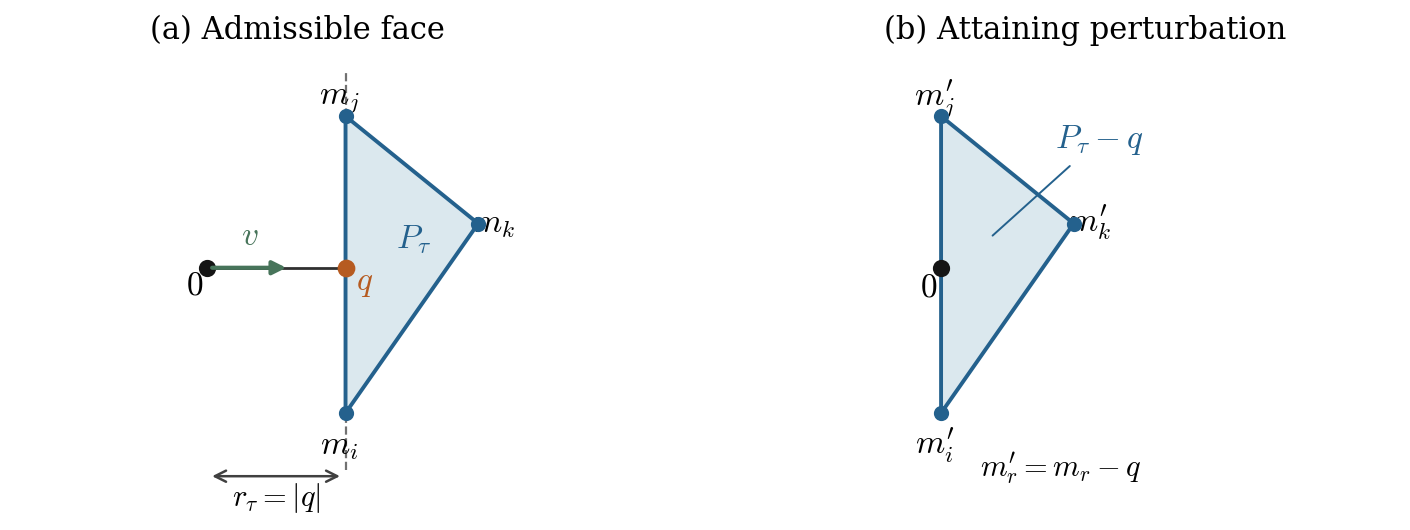

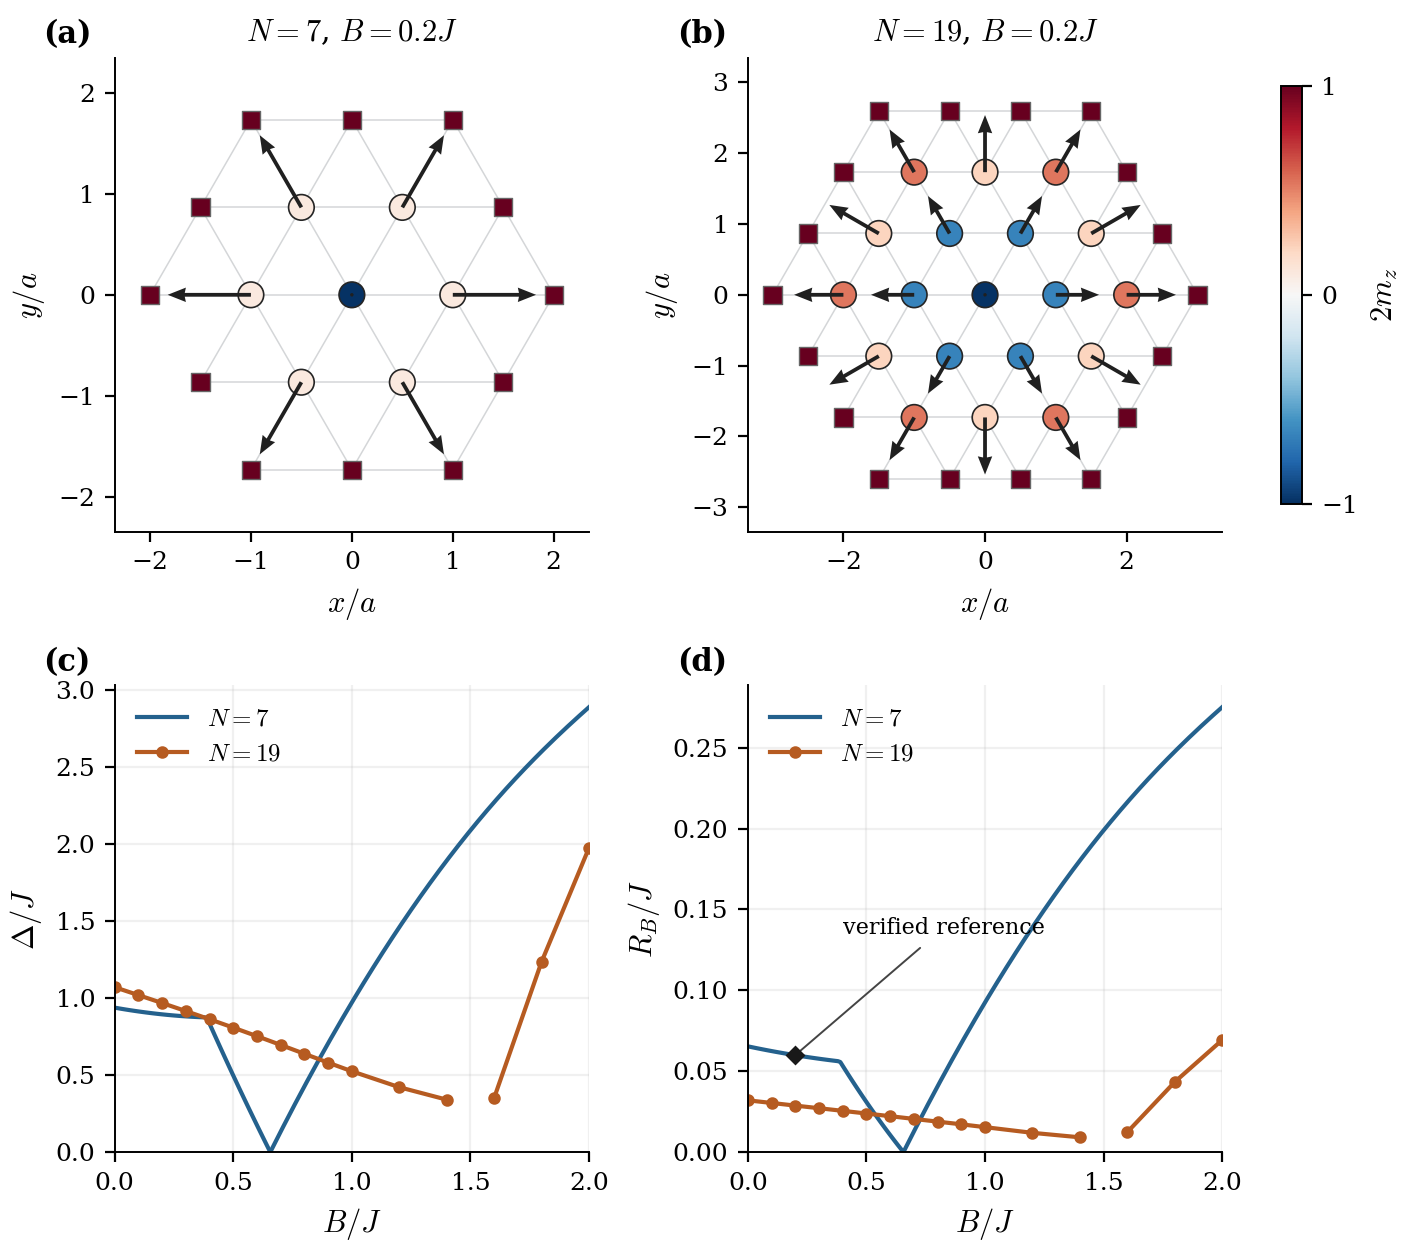

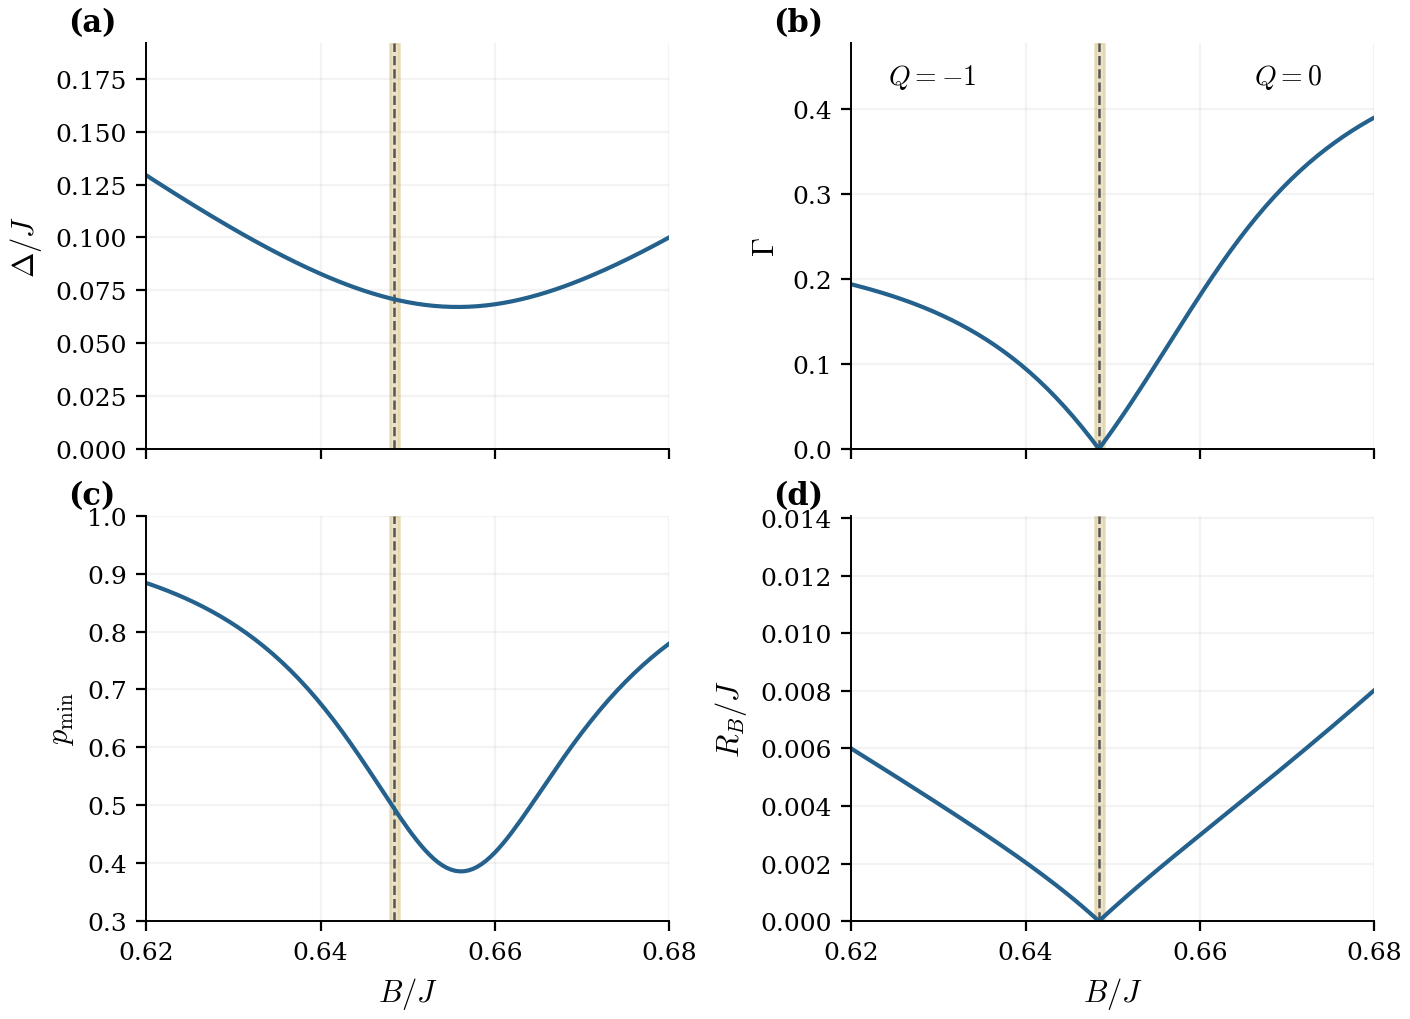

In [6]:
from make_figures import make
paths = make()
for path in paths:
    print(Path(path).name)
for name in ["admissibility_geometry.png", "flakes_and_bounds.png", "gapped_charge_change.png"]:
    display(Image(filename=str(supplement.parent / "figures" / name)))

## Interpretation

At $N=7$, $B_0/J=0.2$, and zero transverse field, the exact certificate gives $Q=-1$ and $R_B/J>0.05992$. Thus all fields satisfying $|B/J-0.2|<0.05992$ have the same reconstructed ground-state charge.

With $(h_x,h_y)=(0.2,0.07)$, the exact endpoint degrees on $[0.648,0.649]$ are $-1$ and $0$, while throughout that interval the spectral gap exceeds $0.0672$ and every local polarization exceeds $0.442$. The charge therefore changes through a failure of the spherical reconstruction. This does not by itself identify a many-body topological phase transition or a physical decay time.